In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("data/datos_prueba_v2.csv", sep=";")

df.head()

,site_id,date,product_id,category1_id,hour,units,total,site_name
0,60060.0,2022-03-03,2010029,119,8,1.0,4.70,Tienda Norte
1,60060.0,2022-02-06,2010029,119,23,2.0,9.40,Tienda Norte
2,NaN,2022-02-06,3140206,119,8,1.0,4.50,Tienda Norte
3,60060.0,2022-02-21,2010520,119,20,1.0,4.90,Tienda Norte
4,60970.0,2022-01-20,3140194,119,11,1.0,4.45,Tienda Sur


In [ ]:
# 1. Dimensiones
filas, columnas = df.shape

print(f"Número de filas: {filas}")
print(f"Número de columnas: {columnas}")

Número de filas: 104903
Número de columnas: 8


In [ ]:
# 2. Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104903 entries, 0 to 104902
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   site_id       99713 non-null   float64
 1   date          104903 non-null  str    
 2   product_id    104903 non-null  int64  
 3   category1_id  104903 non-null  int64  
 4   hour          104903 non-null  int64  
 5   units         99707 non-null   float64
 6   total         99660 non-null   float64
 7   site_name     104903 non-null  str    
dtypes: float64(3), int64(3), str(2)
memory usage: 6.4 MB


In [5]:
df.describe()

,site_id,product_id,category1_id,hour,units,total
count,99713.000000,1.049030e+05,104903.000000,104903.000000,99707.000000,99660.000000
mean,60409.399015,2.976287e+06,128.122618,12.801579,2569.989218,5380.377393
std,493.492769,1.448957e+06,16.609062,6.281534,50605.716856,72106.502241
min,60060.000000,2.010001e+06,119.000000,0.000000,-3.000000,-40.000000
25%,60060.000000,2.010008e+06,119.000000,8.000000,1.000000,4.850000
50%,60190.000000,2.010024e+06,119.000000,13.000000,1.000000,5.150000
75%,60970.000000,3.140346e+06,119.000000,18.000000,2.000000,10.000000
max,61602.000000,6.261000e+06,159.000000,23.000000,999999.000000,999999.000000


In [ ]:
# 3. Nulos
nulls = df.isnull().sum()

print(nulls)

site_id         5190
date               0
product_id         0
category1_id       0
hour               0
units           5196
total           5243
site_name          0
dtype: int64


Aquí yo no rellenaría todavía los nulos. Primero limpiamos los outliers y eliminamos los site_id nulos, tal como pide el ejercicio.

In [ ]:
## 4. Outliers
def remove_outliers_iqr(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = dataframe[column].between(lower_bound, upper_bound)

    print(f"{column}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"Límite inferior: {lower_bound}")
    print(f"Límite superior: {upper_bound}")
    print(f"Outliers detectados: {(~mask).sum()}")

    return dataframe[mask].copy()

In [9]:
df_clean = df.copy()

for column in ["hour", "units", "total"]:
    df_clean = remove_outliers_iqr(df_clean, column)

hour
Q1: 8.0
Q3: 18.0
Límite inferior: -7.0
Límite superior: 33.0
Outliers detectados: 0
units
Q1: 1.0
Q3: 2.0
Límite inferior: -0.5
Límite superior: 3.5
Outliers detectados: 15362
total
Q1: 4.85
Q3: 9.8
Límite inferior: -2.575000000000002
Límite superior: 17.225
Outliers detectados: 9801


In [10]:
df_clean.shape

(79740, 8)

In [ ]:
## 5. Eliminar site_id nulos
df_clean = df_clean.dropna(subset=["site_id"])

In [12]:
df_clean["site_id"].isnull().sum()

np.int64(0)

In [ ]:
## 6. Imputar el resto de nulos
## Yo utilizaría la mediana, porque tenemos valores extremos y la media podría verse afectada.

df_clean["units"] = df_clean["units"].fillna(
    df_clean["units"].median()
)

df_clean["total"] = df_clean["total"].fillna(
    df_clean["total"].median()
)

In [15]:
df_clean.isnull().sum()

site_id         0
date            0
product_id      0
category1_id    0
hour            0
units           0
total           0
site_name       0
dtype: int64

In [17]:
## opcion 2
## si queremos ser más sofisticados, podemos imputar por product_id, porque el precio/cantidad puede variar mucho entre productos:
df_clean["units"] = (
    df_clean.groupby("product_id")["units"]
    .transform(lambda x: x.fillna(x.median()))
)

df_clean["total"] = (
    df_clean.groupby("product_id")["total"]
    .transform(lambda x: x.fillna(x.median()))
)

In [ ]:
## 7. site_id entero
df_clean["site_id"] = df_clean["site_id"].astype(int)

In [18]:
df_clean.to_csv(
    "ventas_limpias.csv",
    index=False
)

In [ ]:
## 8. is_holidays
## El dataset es de 2022, así que podemos construir un calendario de festivos de España para ese año.
holidays_2022 = pd.to_datetime([
    "2022-01-01",
    "2022-01-06",
    "2022-04-15",
    "2022-08-15",
    "2022-10-12",
    "2022-11-01",
    "2022-12-06",
    "2022-12-08",
    "2022-12-26"
])

df_clean["date"] = pd.to_datetime(df_clean["date"])

df_clean["is_holidays"] = (
    df_clean["date"].isin(holidays_2022).astype(int)
)

In [20]:
df_clean["is_holidays"].value_counts()

is_holidays
0    73871
1     1946
Name: count, dtype: int64

In [21]:
## 9. Serie temporal: Tenemos que agrupar por: fecha, tienda, categoría
daily_sales = (
    df_clean
    .groupby(
        ["date", "site_id", "site_name", "category1_id"],
        as_index=False
    )["total"]
    .sum()
    .rename(columns={"total": "daily_sales"})
)

daily_sales.head()

,date,site_id,site_name,category1_id,daily_sales
0,2022-01-01,60060,Tienda Norte,119,280.85
1,2022-01-01,60060,Tienda Norte,159,203.50
2,2022-01-01,60060,Tienda Sur,119,5.15
3,2022-01-01,60060,Tienda Sur,159,11.00
4,2022-01-01,60190,Tienda Oeste,119,673.75


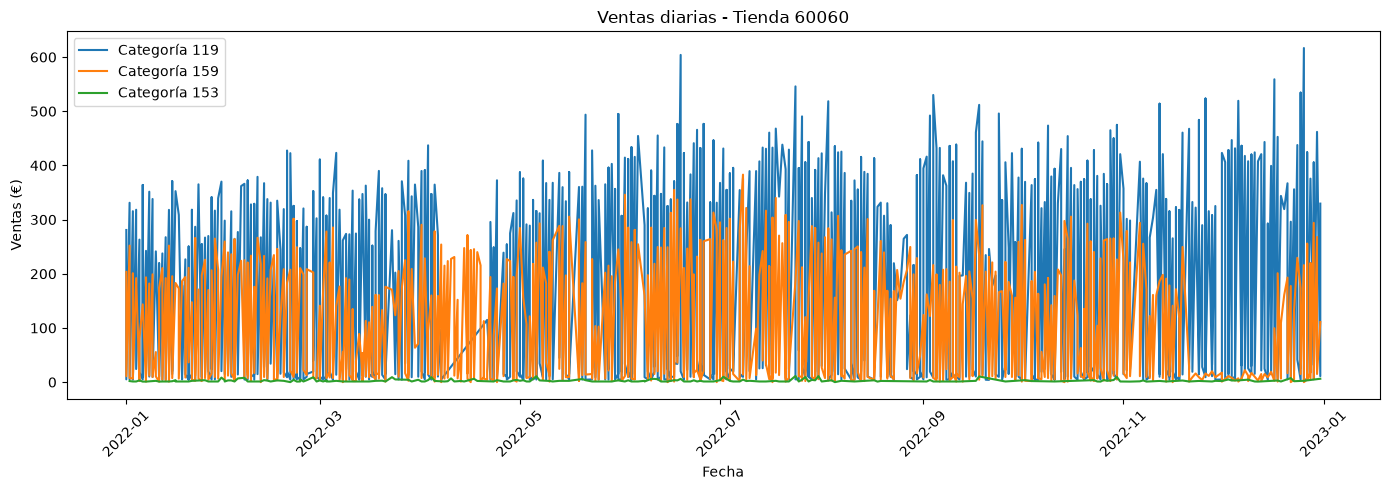

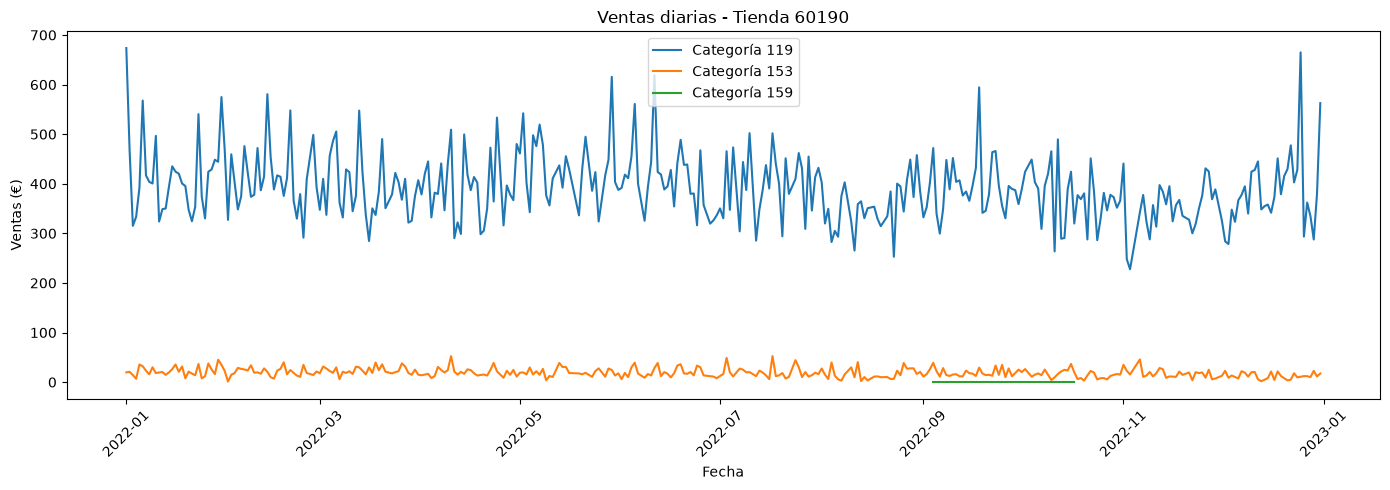

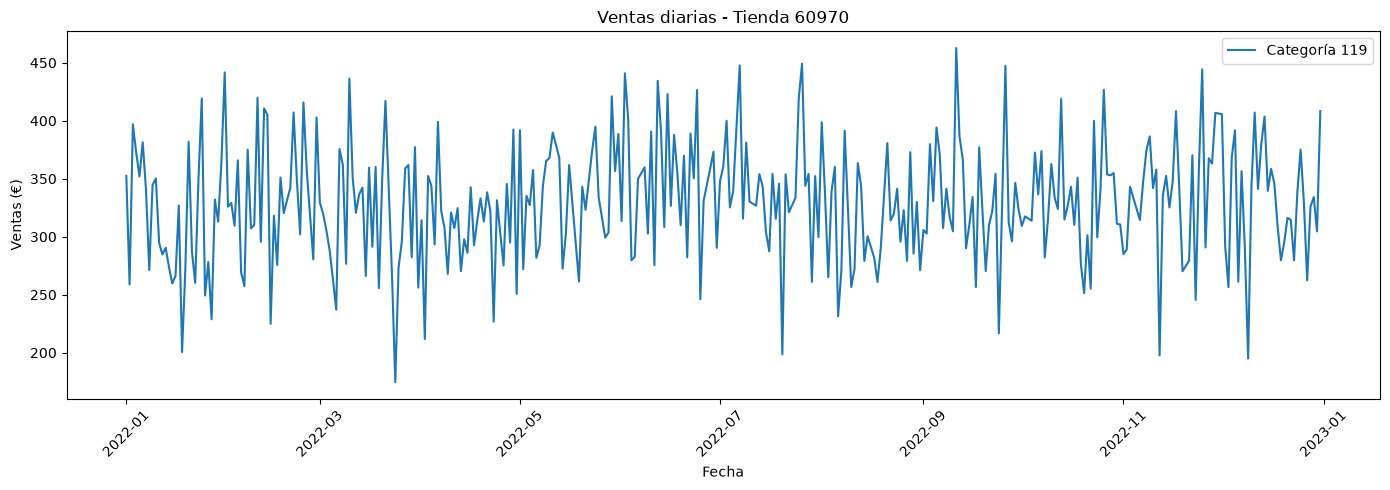

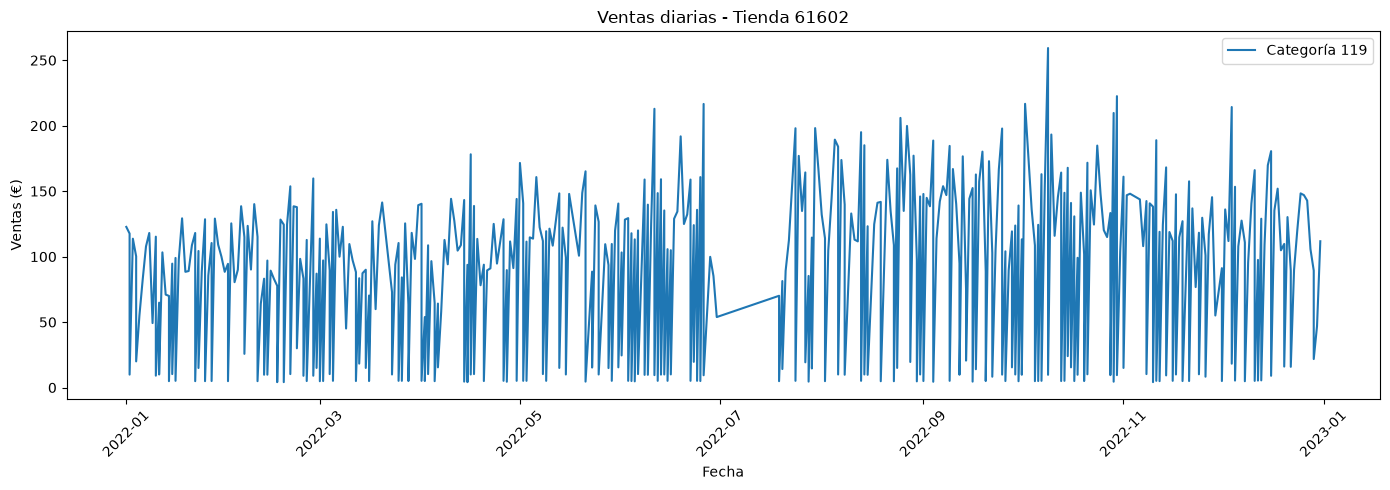

In [22]:
# Plot
sites = daily_sales["site_id"].unique()

for site in sites:

    data = daily_sales[
        daily_sales["site_id"] == site
    ]

    plt.figure(figsize=(14, 5))

    for category in data["category1_id"].unique():

        category_data = data[
            data["category1_id"] == category
        ]

        plt.plot(
            category_data["date"],
            category_data["daily_sales"],
            label=f"Categoría {category}"
        )

    plt.title(f"Ventas diarias - Tienda {site}")
    plt.xlabel("Fecha")
    plt.ylabel("Ventas (€)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
